# Exploratory Data Analysis


,Age,Gender,MaritalStatus,Department,JobRole,JobLevel,YearsAtCompany,MonthlyIncome,PercentSalaryHike,OverTime,JobSatisfaction,WorkLifeBalance,PerformanceRating,Attrition
0,41,Female,Single,Sales,Sales Executive,2,6,5993,11,Yes,4,1,3,Yes
1,49,Male,Married,Research & Development,Research Scientist,2,10,5130,23,No,2,3,4,No
2,37,Male,Single,Research & Development,Laboratory Technician,1,0,2090,15,Yes,3,3,3,Yes
3,33,Female,Married,Research & Development,Research Scientist,1,8,2909,11,Yes,3,3,3,No
4,27,Male,Married,Research & Development,Laboratory Technician,1,2,3468,12,No,2,3,3,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,Male,Married,Research & Development,Laboratory Technician,2,5,2571,17,No,4,3,3,No
1466,39,Male,Married,Research & Development,Healthcare Representative,3,7,9991,15,No,1,3,3,No
1467,27,Male,Married,Research & Development,Manufacturing Director,2,6,6142,20,Yes,2,3,4,No
1468,49,Male,Married,Sales,Sales Executive,2,9,5390,14,No,2,2,3,No


<>:13: SyntaxWarning: invalid escape sequence '\S'
<>:13: SyntaxWarning: invalid escape sequence '\S'
C:\Users\imatu\AppData\Local\Temp\ipykernel_20380\3548010546.py:13: SyntaxWarning: invalid escape sequence '\S'
  df_raw = pd.read_csv('S:\Sem -2\ML2026_Atul\datasets\WA_Fn-UseC_-HR-Employee-Attrition.csv')


--- Missing Values ---
Age                  0
Gender               0
MaritalStatus        0
Department           0
JobRole              0
JobLevel             0
YearsAtCompany       0
MonthlyIncome        0
PercentSalaryHike    0
OverTime             0
JobSatisfaction      0
WorkLifeBalance      0
PerformanceRating    0
Attrition            0
dtype: int64

--- Basic Statistics ---
                    count         mean          std     min     25%     50%  \
Age                1470.0    36.923810     9.135373    18.0    30.0    36.0   
JobLevel           1470.0     2.063946     1.106940     1.0     1.0     2.0   
YearsAtCompany     1470.0     7.008163     6.126525     0.0     3.0     5.0   
MonthlyIncome      1470.0  6502.931293  4707.956783  1009.0  2911.0  4919.0   
PercentSalaryHike  1470.0    15.209524     3.659938    11.0    12.0    14.0   
JobSatisfaction    1470.0     2.728571     1.102846     1.0     2.0     3.0   
WorkLifeBalance    1470.0     2.761224     0.706476     1.0    

C:\Users\imatu\AppData\Local\Temp\ipykernel_20380\3548010546.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Attrition', palette='viridis')


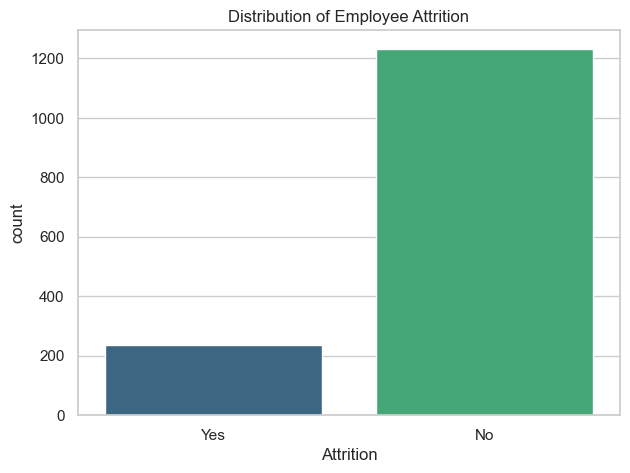

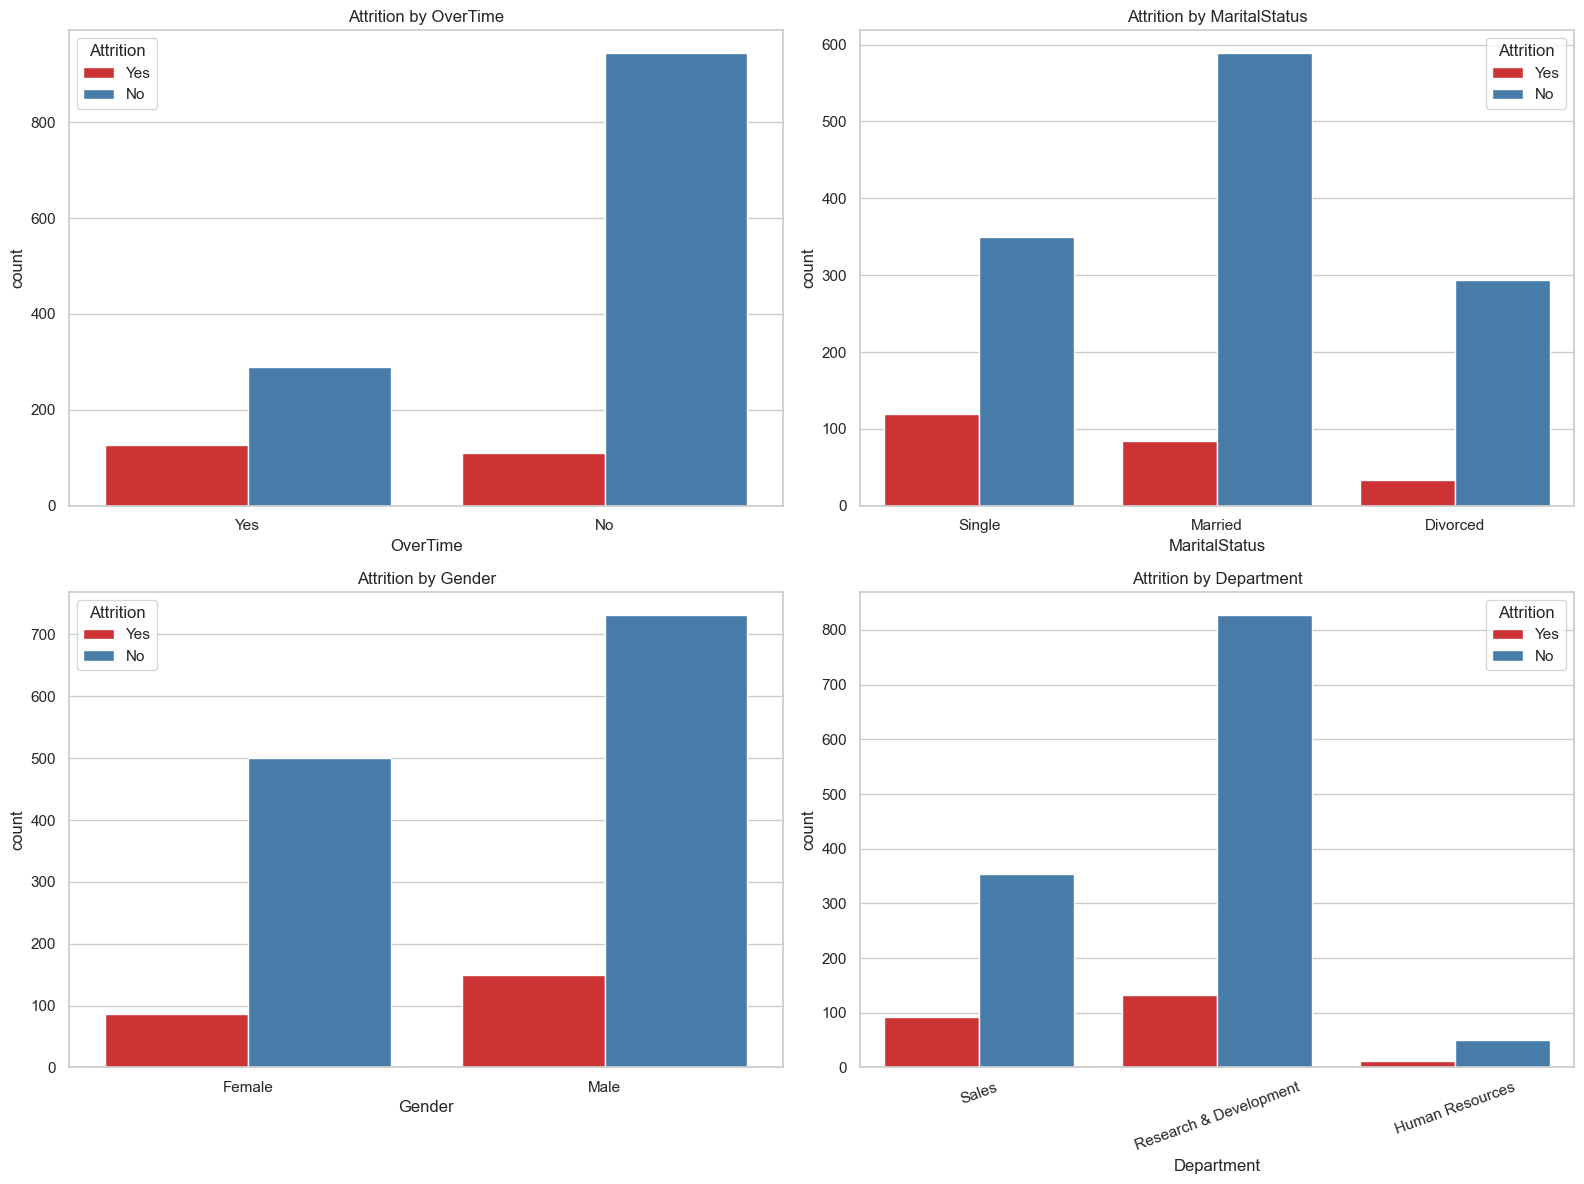

C:\Users\imatu\AppData\Local\Temp\ipykernel_20380\3548010546.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y=col, palette='coolwarm', ax=axes[i])
C:\Users\imatu\AppData\Local\Temp\ipykernel_20380\3548010546.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y=col, palette='coolwarm', ax=axes[i])
C:\Users\imatu\AppData\Local\Temp\ipykernel_20380\3548010546.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y=col, palette='coolwarm', ax=axes[i])
C:\Users\imatu\A

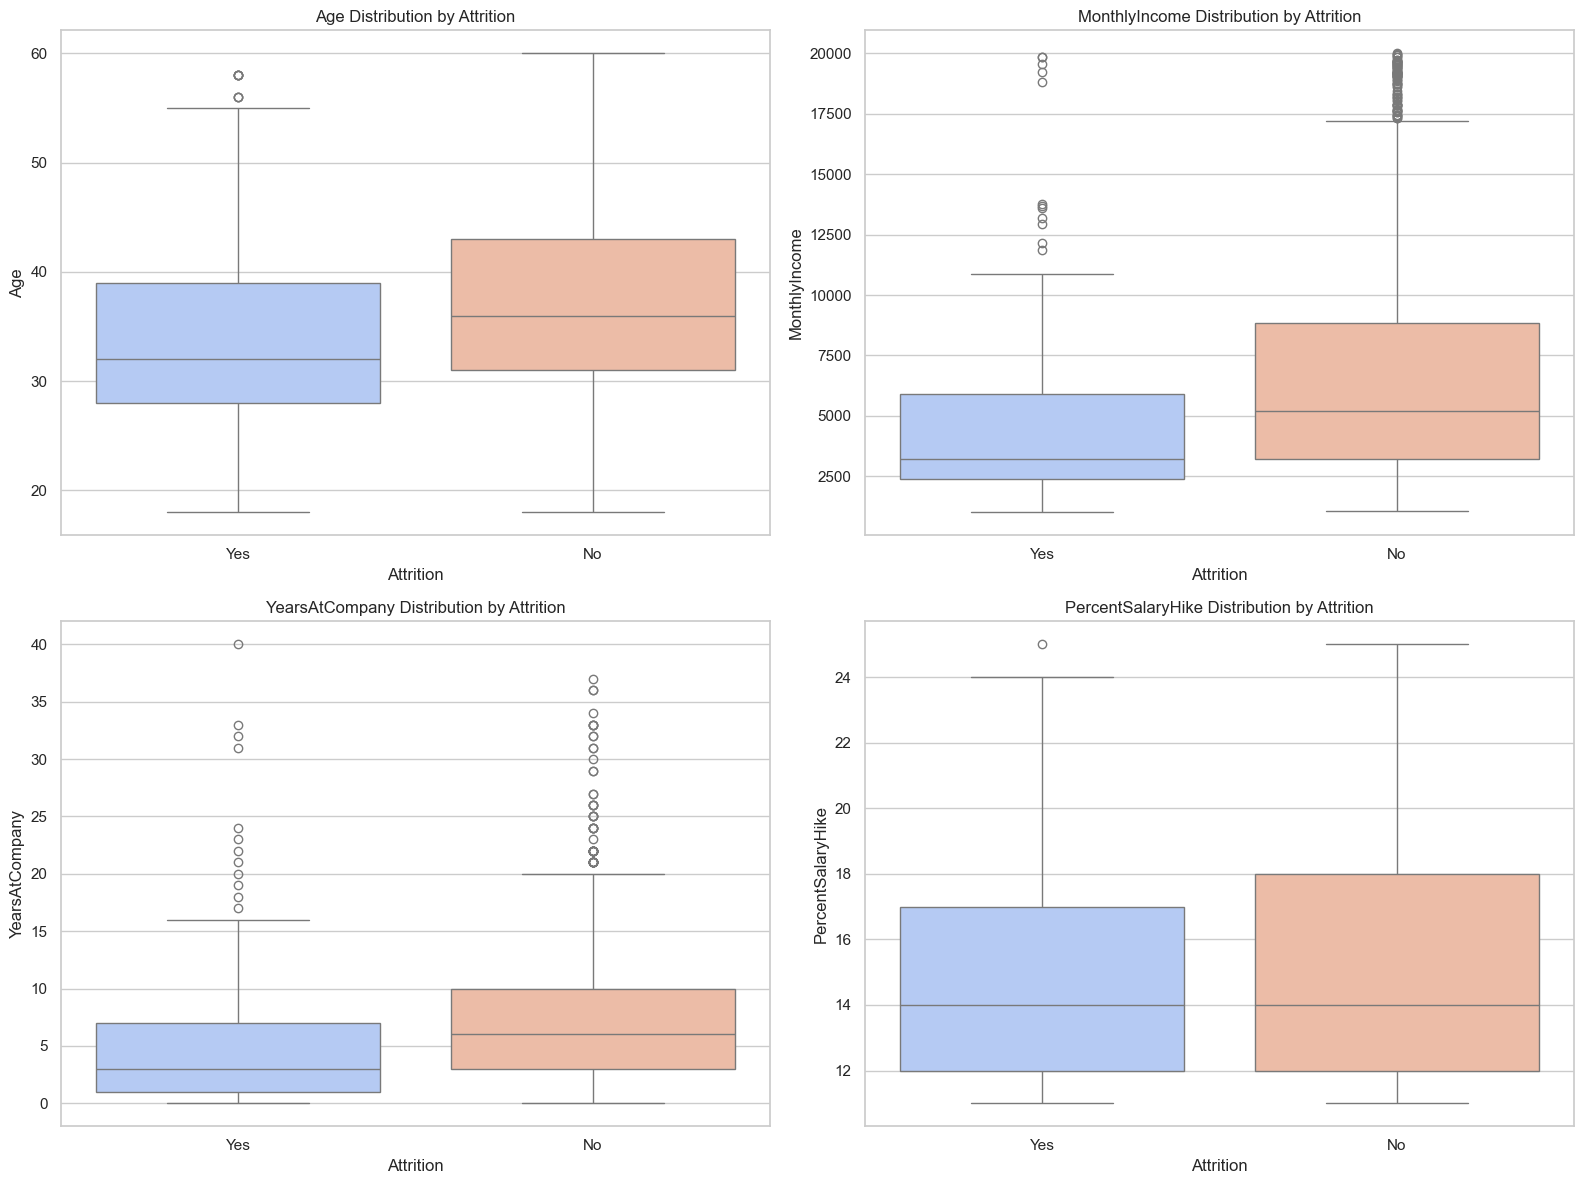

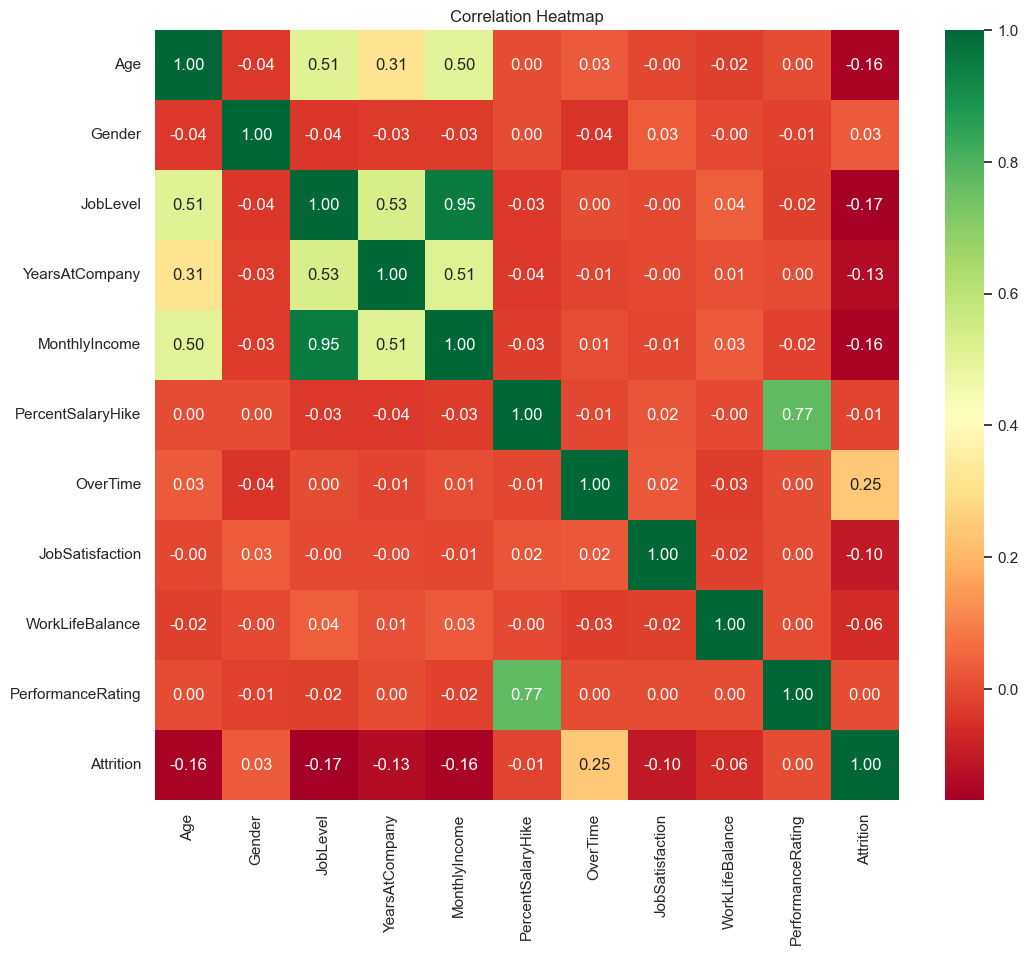

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np



# ---------------------------------------------------------
# Step 1: Load and Filter Data
# ---------------------------------------------------------
try:
    df_raw = pd.read_csv('S:\Sem -2\ML2026_Atul\datasets\WA_Fn-UseC_-HR-Employee-Attrition.csv')
except FileNotFoundError:
    print("Error: File not found.")

selected_columns = [
    'Age', 'Gender', 'MaritalStatus', 'Department', 'JobRole', 'JobLevel', 
    'YearsAtCompany', 'MonthlyIncome', 'PercentSalaryHike', 'OverTime', 
    'JobSatisfaction', 'WorkLifeBalance', 'PerformanceRating', 'Attrition'
]
df = df_raw[selected_columns].copy()

# ---------------------------------------------------------
# Step 2: Data Inspection
# ---------------------------------------------------------
print("--- Missing Values ---")
print(df.isnull().sum())
print("\n--- Basic Statistics ---")
print(df.describe().T)

# ---------------------------------------------------------
# Step 3: Comprehensive Visualization
# ---------------------------------------------------------

# 3.1 Univariate Analysis
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Attrition', palette='viridis')
plt.title('Distribution of Employee Attrition')
plt.show()

# 3.2 Bivariate Analysis: Categorical Features (Looping through them)
# We use a loop here to create 4 plots automatically. It's cleaner!
cat_cols = ['OverTime', 'MaritalStatus', 'Gender', 'Department']
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten() # Flattens the 2x2 grid so we can loop easily

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, hue='Attrition', palette='Set1', ax=axes[i])
    axes[i].set_title(f'Attrition by {col}')
    if col == 'Department':
        axes[i].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

# 3.3 Bivariate Analysis: Numerical Features (Looping through them)
num_cols = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'PercentSalaryHike']
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='Attrition', y=col, palette='coolwarm', ax=axes[i])
    axes[i].set_title(f'{col} Distribution by Attrition')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Step 4: Correlation Analysis (Simplified)
# ---------------------------------------------------------

# Create a copy
df_encoded = df.copy()

# SIMPLE MAPPING (The easy way)
df_encoded['Attrition'] = df_encoded['Attrition'].map({'Yes': 1, 'No': 0})
df_encoded['OverTime'] = df_encoded['OverTime'].map({'Yes': 1, 'No': 0})
df_encoded['Gender'] = df_encoded['Gender'].map({'Male': 1, 'Female': 0})

# Select only numeric columns for the heatmap
numeric_df = df_encoded.select_dtypes(include=[np.number])

plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df.corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()